# Sampling Period Analysis

This notebook loads the latest TMT analysis without interpolation (`interpolate_trajectory=False`).

In [13]:
import sys
sys.path.insert(0, '/home/gianluca/Research/datapruebas_analysis')

import pandas as pd
from pathlib import Path

from src.visualization.compare_interpolation_analysis import (
    _get_run_directory_by_date,
    _load_valid_tmt_trials_by_date,
)
from src.loader.load_last_split import get_run_configuration
from src.visualization.plot_sampling_period import (
    create_figure,
    print_stats,
    COLUMN_NAME,
    NON_CUT_COLUMN_NAME,
)

In [14]:
# Latest analysis without interpolation
RAW_DATE = "2026-01-16_18-57-15"

run_dir = _get_run_directory_by_date(RAW_DATE)
config = get_run_configuration(run_dir)

print(f"Run directory: {run_dir}")
print(f"interpolate_trajectory: {config.get('interpolate_trajectory', False)}")

Run directory: /home/gianluca/Research/datapruebas_analysis/data/hand_analysis/2026-01-16_18-57-15
interpolate_trajectory: False


In [15]:
# Load valid TMT trials
df = _load_valid_tmt_trials_by_date(RAW_DATE)

print(f"Loaded {len(df):,} valid trials")
print(f"Subjects: {df['subject_id'].nunique()}")
df.head()

Excluding 18 subjects without both PART_A and PART_B trials: ['030720fd-dc61-422b-bdf2-2db9457d2f1c', '1d0fc2b7-c2a2-43bd-b00c-ab6b0a7ff722', '1e8869b5-564e-4104-b7e7-84cb6a8edf11', '5f6e5399-a575-4a52-91a7-136356728a8a', '82f8adea-8cec-410e-a7b8-dc3396162402']...


Loaded 5,607 valid trials
Subjects: 366


,subject_id,trial_id,trial_type,is_valid,trial_order_of_appearance,speed_threshold,dispositivo,mano,dispositivo-config,alcohol-drogas,...,nationality,experiment_origin,device,hand,device_config,alcohol_drugs,treatment,pad_usage,final_comment,start_date
0,df0b8572-3570-4c43-ac9b-017fec2adf22,NEUROPRUEBAS_2,PART_A,True,2,0.280745,Mouse,Derecha,si,no,...,Argentino,neuropruebas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,df0b8572-3570-4c43-ac9b-017fec2adf22,NEUROPRUEBAS_3,PART_B,True,3,0.280745,Mouse,Derecha,si,no,...,Argentino,neuropruebas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,df0b8572-3570-4c43-ac9b-017fec2adf22,NEUROPRUEBAS_6,PART_A,True,6,0.280745,Mouse,Derecha,si,no,...,Argentino,neuropruebas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,df0b8572-3570-4c43-ac9b-017fec2adf22,NEUROPRUEBAS_8,PART_A,True,8,0.280745,Mouse,Derecha,si,no,...,Argentino,neuropruebas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,df0b8572-3570-4c43-ac9b-017fec2adf22,NEUROPRUEBAS_10,PART_A,True,10,0.280745,Mouse,Derecha,si,no,...,Argentino,neuropruebas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



STATISTICS FOR mean_sampling_period
Count:  5,607
Mean:   25.6184
Median: 24.3377
Std:    6.9823
Min:    6.9962
Max:    72.4342


STATISTICS FOR non_cut_mean_sampling_period
Count:  5,607
Mean:   26.0674
Median: 24.9305
Std:    6.7377
Min:    7.6431
Max:    77.3943



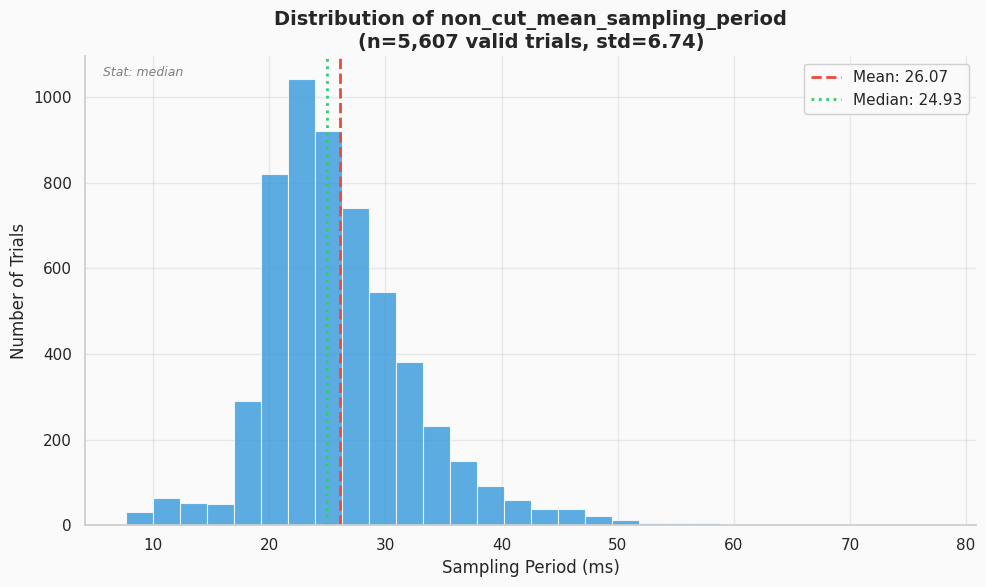

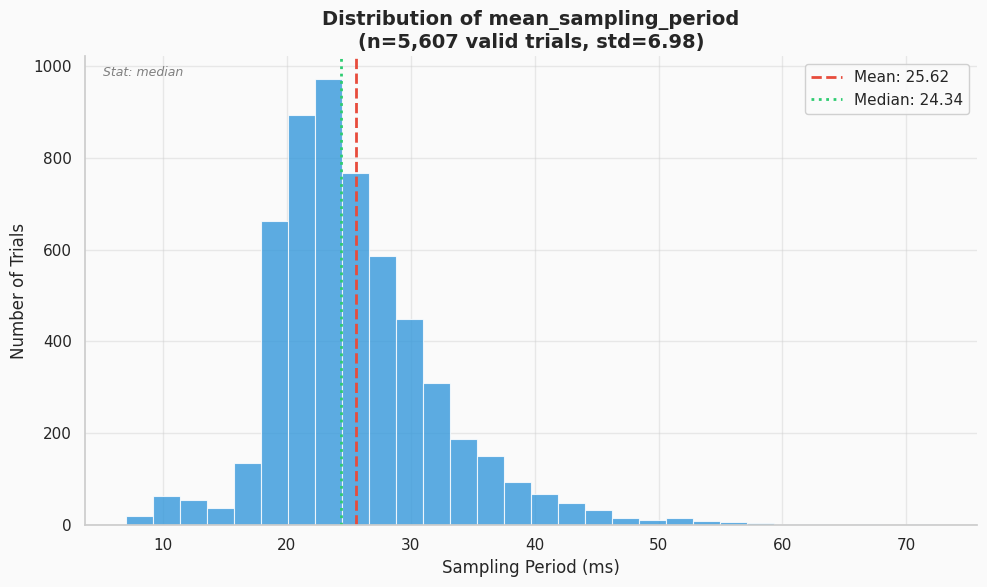

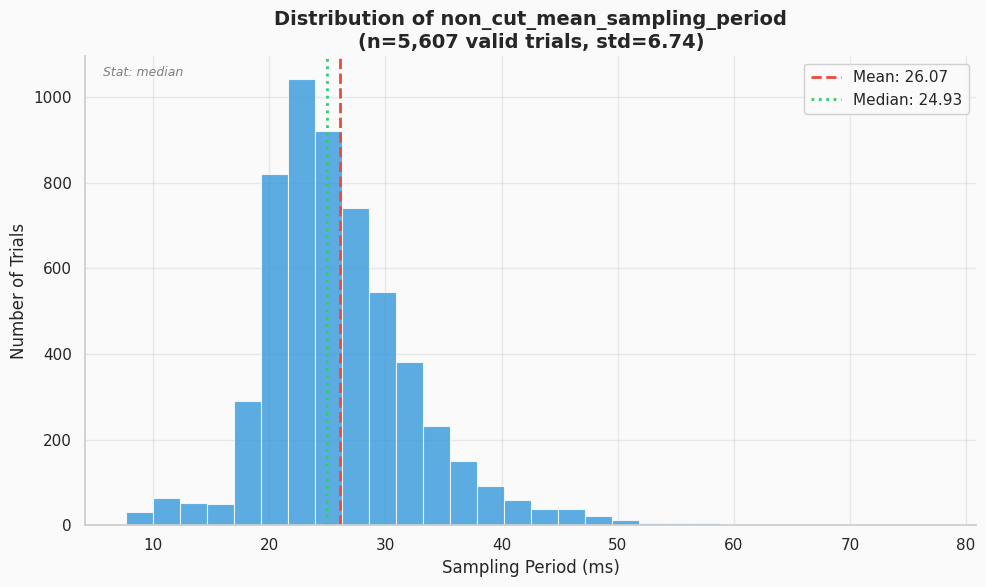

In [16]:
# Plot sampling period distribution (mean)
print_stats(df, "mean_sampling_period")
create_figure(df, column_name="mean_sampling_period", bins=30)

print_stats(df, "non_cut_mean_sampling_period")
create_figure(df, column_name="non_cut_mean_sampling_period", bins=30)


STATISTICS FOR median_sampling_period
Count:  5,607
Mean:   16.8283
Median: 17.0000
Std:    2.4629
Min:    6.0000
Max:    33.0000


STATISTICS FOR non_cut_median_sampling_period
Count:  5,607
Mean:   16.8293
Median: 17.0000
Std:    2.4617
Min:    6.0000
Max:    33.0000



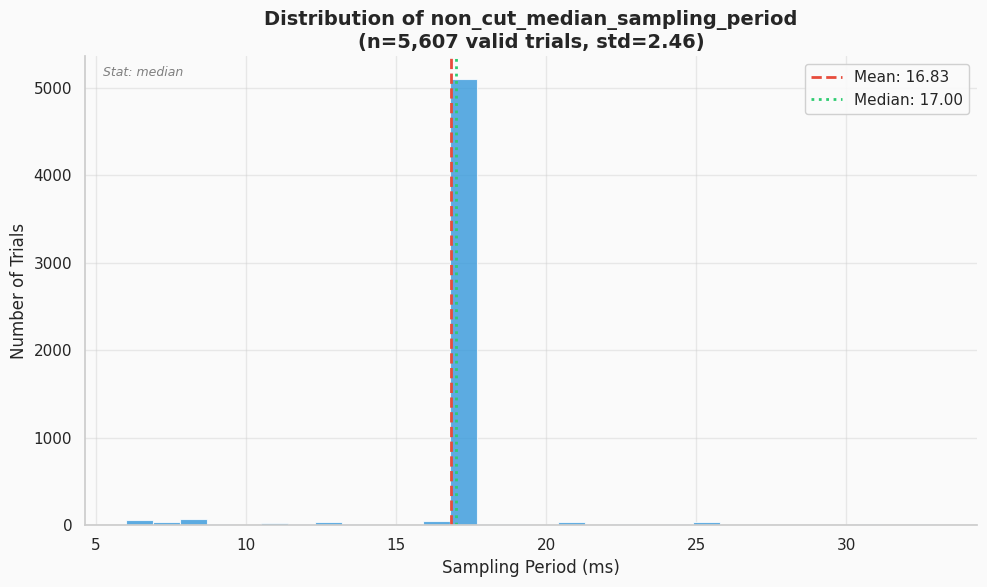

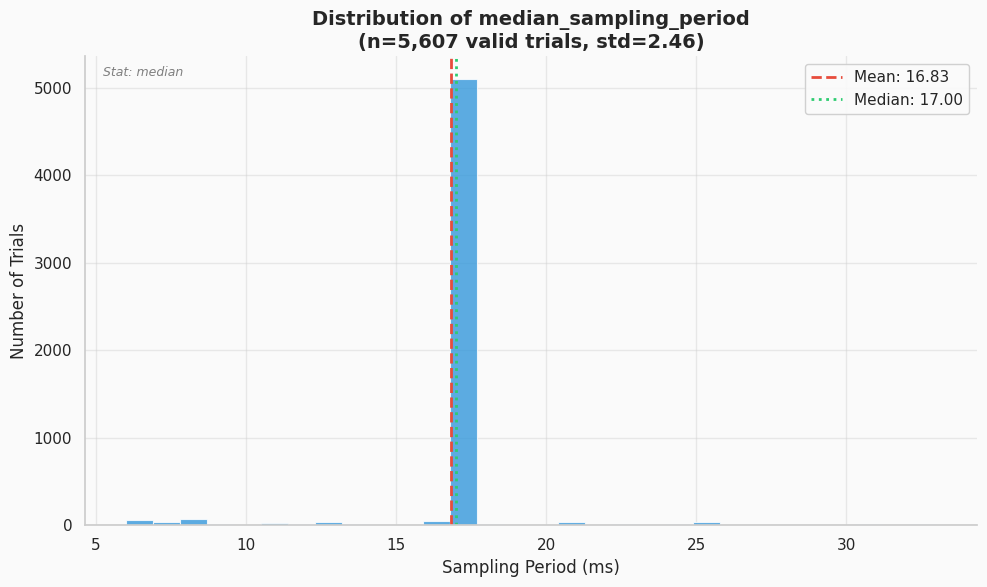

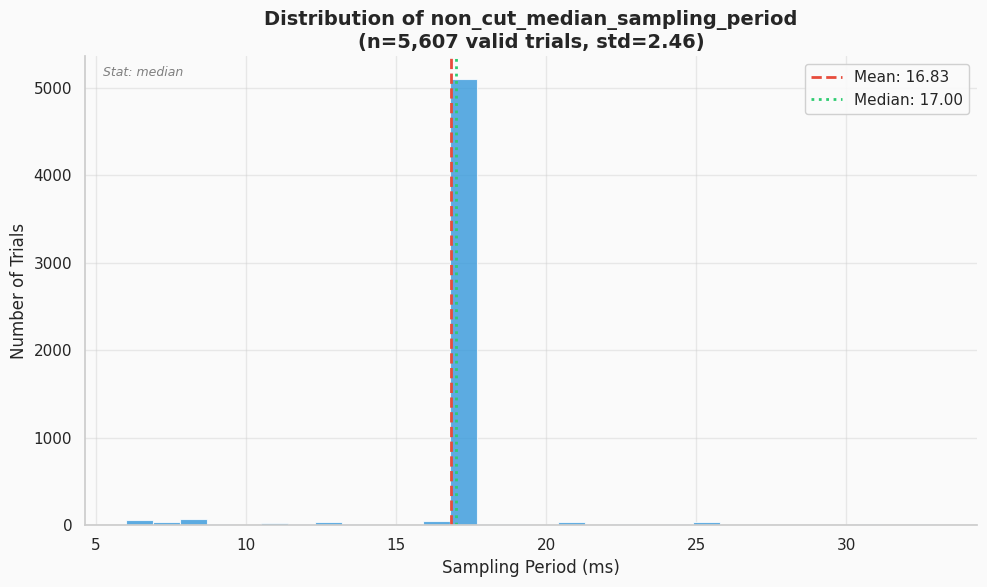

In [17]:
# Plot sampling period distribution
print_stats(df, "median_sampling_period")
create_figure(df, column_name="median_sampling_period", bins=30)

print_stats(df, "non_cut_median_sampling_period")
create_figure(df, column_name=NON_CUT_COLUMN_NAME, bins=30)

In [18]:
# Also load the raw CSV if needed
df_raw = pd.read_csv(run_dir / "analysis.csv")
print(f"Raw analysis shape: {df_raw.shape}")
df_raw.head()

Raw analysis shape: (7508, 126)


,subject_id,trial_id,trial_type,is_valid,trial_order_of_appearance,speed_threshold,dispositivo,mano,dispositivo-config,alcohol-drogas,...,nationality,experiment_origin,device,hand,device_config,alcohol_drugs,treatment,pad_usage,final_comment,start_date
0,df0b8572-3570-4c43-ac9b-017fec2adf22,NEUROPRUEBAS_2,PART_A,True,2,0.280745,Mouse,Derecha,si,no,...,Argentino,neuropruebas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,df0b8572-3570-4c43-ac9b-017fec2adf22,NEUROPRUEBAS_3,PART_B,True,3,0.280745,Mouse,Derecha,si,no,...,Argentino,neuropruebas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,df0b8572-3570-4c43-ac9b-017fec2adf22,NEUROPRUEBAS_4,PART_A,False,4,0.280745,Mouse,Derecha,si,no,...,Argentino,neuropruebas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,df0b8572-3570-4c43-ac9b-017fec2adf22,NEUROPRUEBAS_5,PART_B,False,5,0.280745,Mouse,Derecha,si,no,...,Argentino,neuropruebas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,df0b8572-3570-4c43-ac9b-017fec2adf22,NEUROPRUEBAS_6,PART_A,True,6,0.280745,Mouse,Derecha,si,no,...,Argentino,neuropruebas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# Show configuration
config

{'timestamp': '2026-01-16_18-57-15',
 'correct_targets_minimum': 10,
 'cut_criteria': 'MINIMUM_TARGETS',
 'consecutive_points': 5,
 'calculate_crosses': False,
 'interpolate_trajectory': False,
 'random_state': 78,
 'test_size': 1,
 'metadata_path': '/home/gianluca/Research/datapruebas_analysis/data/metadata/metadata.csv',
 'train_subject_ids': ['df0b8572-3570-4c43-ac9b-017fec2adf22',
  '19c4d2f0-d267-4cc9-85a1-bc8890302849',
  'b835d0ae-65eb-47fb-911b-2e2103e29ce9',
  '1e200df4-7a6b-4aab-b96b-8e8c8497716a',
  '4689aab8-6e05-4619-896f-683fa632f662',
  'bbbb7d3f-5b50-4298-92dd-23fb22d690a8',
  '9b8b167b-7e64-4347-a579-ad8c2ba4025f',
  'facundoruiz2610@gmail.com-tmt-plugin_96.csv',
  '6a76c25a-9cfa-45ec-bb4d-bbd759d9c166',
  '282ea475-71b7-4957-918b-ab41d445bae2',
  'ff7bc994-9737-4c2e-b751-42cf92256b99',
  '8c773b9f-849e-4a87-ab9e-dd3a927604a5',
  'ad957190-b355-4f4e-b6f6-7b13e34d4ea9',
  'ab4587e9-e129-47d5-b883-f20ebda12b3f',
  'b1368f7d-47b5-45dd-83f4-5167eca84158',
  'b5dfe38f-8325-

In [20]:
# Count trials with mean_sampling_period >= 50ms
threshold = 50
n_above = (df['mean_sampling_period'] >= threshold).sum()
n_total = len(df)
pct = n_above / n_total * 100

print(f"Trials with mean_sampling_period >= {threshold}ms: {n_above:,} / {n_total:,} ({pct:.1f}%)")

Trials with mean_sampling_period >= 50ms: 52 / 5,607 (0.9%)


In [21]:
# Count trials with mean_sampling_period >= 40ms
threshold = 40
n_above = (df['mean_sampling_period'] >= threshold).sum()
n_total = len(df)
pct = n_above / n_total * 100

print(f"Trials with mean_sampling_period >= {threshold}ms: {n_above:,} / {n_total:,} ({pct:.1f}%)")

Trials with mean_sampling_period >= 40ms: 222 / 5,607 (4.0%)


In [22]:
# Function to check if filtering by threshold would cause us to lose subjects

def check_subject_loss(df: pd.DataFrame, threshold: float) -> dict:
    """
    Check if filtering out trials with mean_sampling_period >= threshold
    would cause us to lose subjects (no Part A or Part B trials left).
    
    Args:
        df: DataFrame with valid TMT trials
        threshold: Sampling period threshold in ms
        
    Returns:
        dict with analysis results
    """
    # Count trials before filtering
    n_trials_before = len(df)
    
    # Filter to keep only trials with mean_sampling_period < threshold
    df_filtered = df[df['mean_sampling_period'] < threshold].copy()
    
    # Count trials after filtering
    n_trials_after = len(df_filtered)
    trials_lost = n_trials_before - n_trials_after
    
    # Get subjects before filtering
    subjects_before = set(df['subject_id'].unique())
    n_subjects_before = len(subjects_before)
    
    # Check which subjects have Part A and Part B after filtering
    def get_part(trial_type):
        tt = str(trial_type).upper()
        if 'PART_A' in tt: return 'A'
        if 'PART_B' in tt: return 'B'
        return None
    
    df_filtered['Part'] = df_filtered['trial_type'].apply(get_part)
    
    subjects_with_a = set(df_filtered[df_filtered['Part'] == 'A']['subject_id'].unique())
    subjects_with_b = set(df_filtered[df_filtered['Part'] == 'B']['subject_id'].unique())
    subjects_with_both = subjects_with_a & subjects_with_b
    
    n_subjects_after = len(subjects_with_both)
    lost_subjects = subjects_before - subjects_with_both
    
    # Print results
    print(f"Threshold: mean_sampling_period >= {threshold}ms")
    print(f"Trials: {n_trials_before} -> {n_trials_after} (lost {trials_lost})")
    print(f"Subjects before filtering: {n_subjects_before}")
    print(f"Subjects with both Part A and Part B after filtering: {n_subjects_after}")
    print(f"Subjects lost: {len(lost_subjects)}")
    
    if lost_subjects:
        print(f"\nLost subject IDs:")
        for s in sorted(lost_subjects):
            print(f"  - {s}")
    
    return {
        'threshold': threshold,
        'subjects_before': n_subjects_before,
        'subjects_after': n_subjects_after,
        'lost_subjects': lost_subjects,
        'trials_before': n_trials_before,
        'trials_after': n_trials_after,
        'trials_lost': trials_lost,
    }

In [23]:
# Test with threshold = 50ms
check_subject_loss(df, threshold=50)

Threshold: mean_sampling_period >= 50ms
Trials: 5607 -> 5555 (lost 52)
Subjects before filtering: 366
Subjects with both Part A and Part B after filtering: 362
Subjects lost: 4

Lost subject IDs:
  - 40b587a7-e0e6-4f46-97a4-1c4910ef5742
  - 45deabdb-bc51-4803-b175-0914be70fac5
  - 4fb9c111-8a21-4256-8269-4607e9990f0e
  - e1bf5ce7-cb79-410f-92d7-023f48fe2841


{'threshold': 50,
 'subjects_before': 366,
 'subjects_after': 362,
 'lost_subjects': {'40b587a7-e0e6-4f46-97a4-1c4910ef5742',
  '45deabdb-bc51-4803-b175-0914be70fac5',
  '4fb9c111-8a21-4256-8269-4607e9990f0e',
  'e1bf5ce7-cb79-410f-92d7-023f48fe2841'},
 'trials_before': 5607,
 'trials_after': 5555,
 'trials_lost': 52}

Threshold: mean_sampling_period >= 50.0ms
Trials: 5607 -> 5555 (lost 52)
Subjects before filtering: 366
Subjects with both Part A and Part B after filtering: 362
Subjects lost: 4

Lost subject IDs:
  - 40b587a7-e0e6-4f46-97a4-1c4910ef5742
  - 45deabdb-bc51-4803-b175-0914be70fac5
  - 4fb9c111-8a21-4256-8269-4607e9990f0e
  - e1bf5ce7-cb79-410f-92d7-023f48fe2841

Threshold: mean_sampling_period >= 40.0ms
Trials: 5607 -> 5385 (lost 222)
Subjects before filtering: 366
Subjects with both Part A and Part B after filtering: 357
Subjects lost: 9

Lost subject IDs:
  - 06c54d33-ee13-40de-bc70-15f640c8c325
  - 1b5a21cc-623f-4005-9f66-968ecfadff51
  - 40b587a7-e0e6-4f46-97a4-1c4910ef5742
  - 45deabdb-bc51-4803-b175-0914be70fac5
  - 4fb9c111-8a21-4256-8269-4607e9990f0e
  - 6838a4c2-ce67-4bd1-931f-2227776ce2a4
  - 76d152ce-c8a1-4db1-96f1-8a90bf095c66
  - c2030111-c98e-4a81-b7e8-36058ba9dd0f
  - e1bf5ce7-cb79-410f-92d7-023f48fe2841

Threshold: mean_sampling_period >= 33.33ms
Trials: 5607 -> 4962 (los

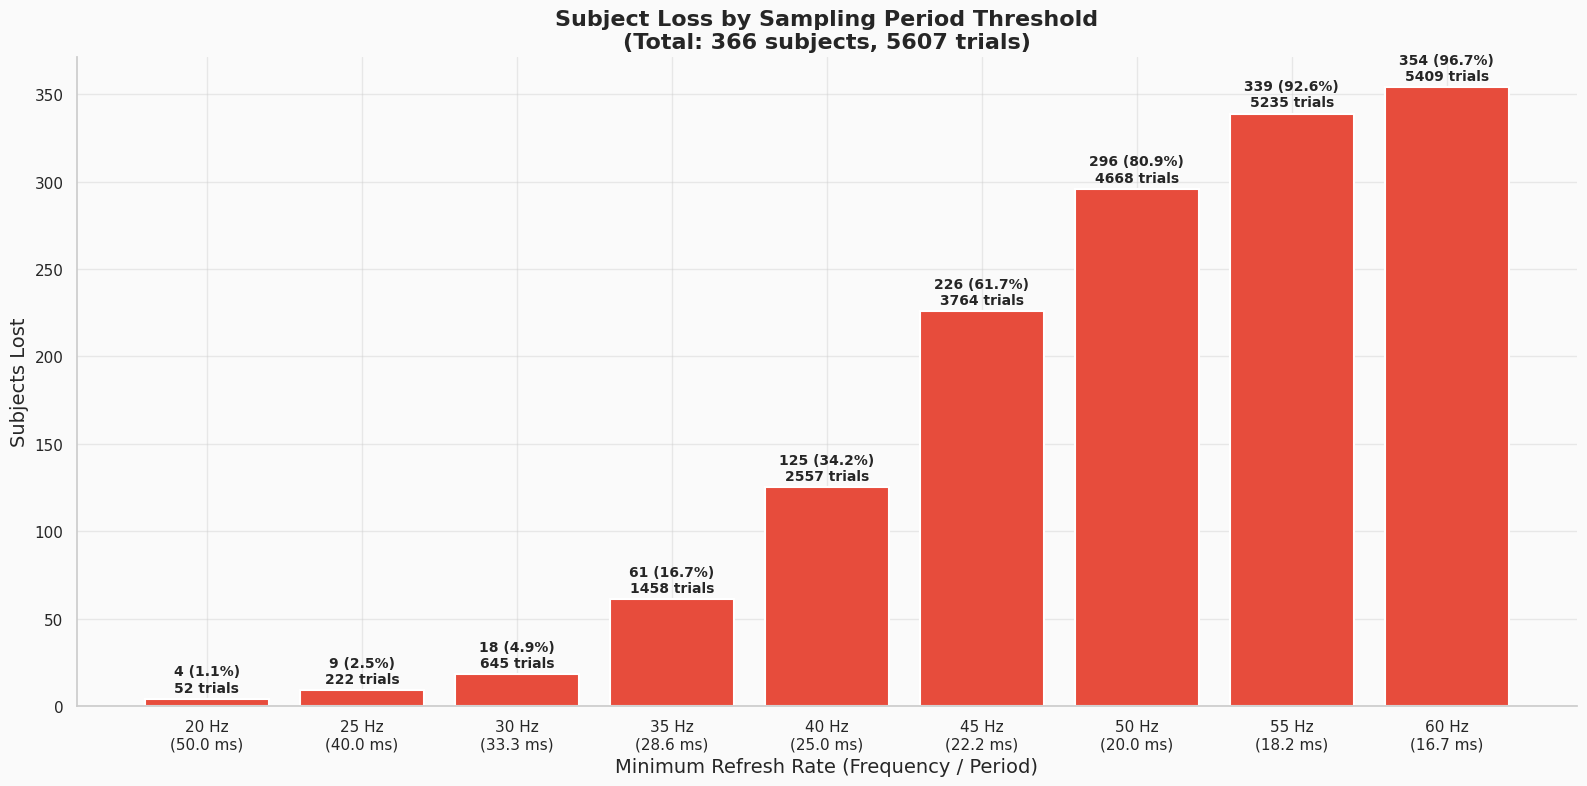

In [24]:
import matplotlib.pyplot as plt
from src import config
import os

# Thresholds based on refresh rates
thresholds = [
    (20, 50.00),    # 20 Hz
    (25, 40.00),    # 25 Hz
    (30, 33.33),    # 30 Hz
    (35, 28.57),    # 35 Hz
    (40, 25.00),    # 40 Hz
    (45, 22.22),    # 45 Hz
    (50, 20.00),    # 50 Hz
    (55, 18.18),    # 55 Hz
    (60, 16.67),    # 60 Hz
]

# Calculate subject loss for each threshold
results = []
for freq, period in thresholds:
    result = check_subject_loss(df, threshold=period)
    result['frequency'] = freq
    results.append(result)
    print()

# Create plot
fig, ax = plt.subplots(figsize=(16, 8))

frequencies = [r['frequency'] for r in results]
periods = [r['threshold'] for r in results]
subjects_lost = [len(r['lost_subjects']) for r in results]
trials_lost = [r['trials_lost'] for r in results]
subjects_before = results[0]['subjects_before']
trials_before = results[0]['trials_before']

# Bar plot
x = range(len(thresholds))
bars = ax.bar(x, subjects_lost, color='#e74c3c', edgecolor='white', linewidth=1.5)

# Add value labels on bars (subjects lost + % + trials lost)
for bar, n_subj, n_trials in zip(bars, subjects_lost, trials_lost):
    height = bar.get_height()
    pct_subj = n_subj / subjects_before * 100
    ax.annotate(f'{n_subj} ({pct_subj:.1f}%)\n{n_trials} trials',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# X-axis labels with frequency and period
labels = [f'{freq} Hz\n({period:.1f} ms)' for freq, period in thresholds]
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)

ax.set_xlabel('Minimum Refresh Rate (Frequency / Period)', fontsize=14)
ax.set_ylabel('Subjects Lost', fontsize=14)
ax.set_title(f'Subject Loss by Sampling Period Threshold\n(Total: {subjects_before} subjects, {trials_before} trials)', fontsize=16)

# Add horizontal line at 0
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save figure
os.makedirs(config.FIGURES_DIR, exist_ok=True)
output_path = os.path.join(config.FIGURES_DIR, 'subject_loss_by_sampling_period.png')
fig.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {output_path}")

plt.show()